In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.stats import nbinom
import seaborn as sns
from statsmodels.iolib.summary2 import summary_col
import linearmodels.panel as lmp

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline


{"tags": ["hide_input"]}

{'tags': ['hide_input']}

# Pregunta 1
Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [2]:
df = pd.read_csv('../../data/panel_eps.csv')
df.describe()

{"tags": ["hide_input"]}

{'tags': ['hide_input']}

Si no está trabajando y tiene un Nan en sus horas de trabajo, se cambiará por un cero. 

In [3]:
a=df["hours"].isna().sum()
df.loc[df['hours'].isna() & df['informal'].isna() & df['selfemp'].isna() & df['publicemp'].isna(), 'hours'] = 0
b=df["hours"].isna().sum()
print(f'Se han transformado {a-b} Nans')


{"tags": ["hide_input"]}

Se han transformado 41059 Nans


{'tags': ['hide_input']}

Si el salario tiene un NaN y las horas trabajadas tienen un NaN o un 0, se reemplazará el NaN del salario por un 0

In [4]:
a=df["wage"].isna().sum()
df.loc[df['hours'].isna() & df['wage'].isna(), 'wage'] = 0
df.loc[df['hours']==0 & df['wage'].isna(), 'wage'] = 0
b=df["wage"].isna().sum()
print(f'Se han transformado {a-b} Nans')

{"tags": ["hide_input"]}

Se han transformado 41181 Nans


{'tags': ['hide_input']}

Para las variables binarias,"illness","cronica","nocronica","mental","informal","selfemp","publicemp","cotizando","sistema" y "kids" se reemplazarán los Nans por ceros

In [5]:
a=df.isna().sum().sum()

df["illness"]=df["illness"].fillna(0)
df["cronica"]=df["cronica"].fillna(0)
df["nocronica"]=df["nocronica"].fillna(0)
df["mental"]=df["mental"].fillna(0)
df["informal"]=df["informal"].fillna(0)
df["selfemp"]=df["selfemp"].fillna(0)
df["publicemp"]=df["publicemp"].fillna(0)
df["cotizando"]=df["cotizando"].fillna(0)
df["sistema"]=df["sistema"].fillna(0)
df["kids"]=df["kids"].fillna(0)

b=df.isna().sum().sum()
print(f'Se han transformado {a-b} Nans')

{"tags": ["hide_input"]}

Se han transformado 229091 Nans


{'tags': ['hide_input']}

Eliminaremos las columnas que tengan mas de un 30% de valores nulos (Exceptuando a expecatncy y edu que son necesarias para el modelo).

In [6]:
eliminar=[]
nulos=df.isnull().sum()
for i in range(len(nulos)):
    if nulos[i]/len(df)>0.3:
        if df.columns[i]!= "expectancy" and df.columns[i]!= "edu":
            eliminar.append(df.columns[i])

for i in eliminar:
    print(f'Se ha eliminado {i}')
    df.drop(i,axis=1,inplace=True)
    
{"tags": ["hide_input"]}

Se ha eliminado size
Se ha eliminado occupation
Se ha eliminado fondoa
Se ha eliminado fondob
Se ha eliminado fondoc
Se ha eliminado fondod
Se ha eliminado fondoe


{'tags': ['hide_input']}

Ajuste de la variable edad. Se dejaran edades y no años de nacimiento

In [7]:
for i in range(len(df)):
    if df.loc[i,"edad"]>150:
        df.loc[i,"edad"]=df.loc[i,"year"]+2000-df.loc[i,"edad"]
        
df["edad"]
  
    
{"tags": ["hide_input"]}

{'tags': ['hide_input']}

Análisis de correlación de variables

{'tags': ['hide_input']}

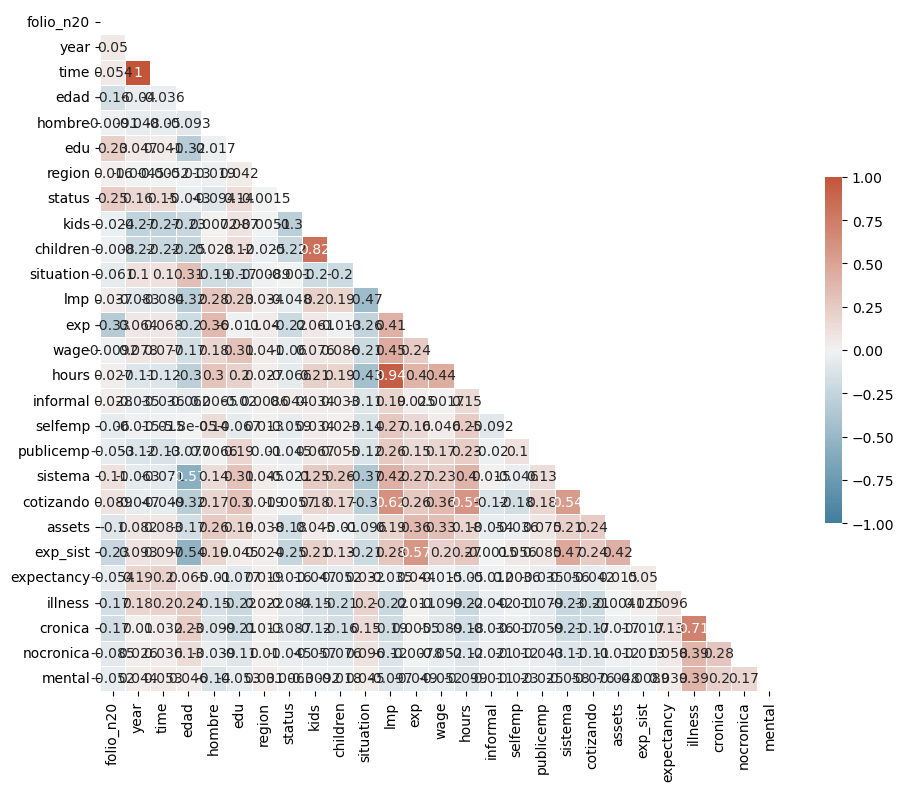

In [8]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, annot=True, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

{"tags": ["hide_input"]}

Eliminaremos las variables time, children, lmp e illness porque pueden ser explicadas por otras variables. También eliminaremos la variable sistema or su alta correlación con la variable cotizando. 

In [9]:
df=df.drop(["time","children","lmp","illness","sistema"],axis=1)


{"tags": ["hide_input"]}

{'tags': ['hide_input']}

Eliminamos aquellas filas cuya expectativa de vida sea mayor a los 110 años, ya que estas probablemente se deban a un error de inputación. Eliminaremos aquellas fila sque tengan valores nulos en las variables expectancy y edu ya que estas son las variables que nos interesa estudiar. También eliminaremos las filas cuya expectativa de vida sea menor que la edad que tenían al momento de responder las preguntas.

In [10]:
for i in range(len(df)):
    if df.loc[i,"expectancy"]>110:
        df.loc[i,"expectancy"]=np.nan

for i in range(len(df)):
    if df.loc[i,"edad"]>df.loc[i,"expectancy"]:
        df.drop(i,inplace=True)
df.dropna(subset=["expectancy","edu"],inplace=True)

{"tags": ["hide_input"]}

{'tags': ['hide_input']}

Para un mejor análisis de resultados, crearemos la variable Expectativa, que será los años extra que espera vivir una persona a partir de ese momento. También estandarizaremos la variable wage, ya que tiene valores mucho más altos que los del resto de variables.

In [11]:
df["Expectativa"]=df["expectancy"]-df["edad"]

df['Wage'] = (df['wage'] - df['wage'].mean()) / df['wage'].std()
df.drop("wage",axis=1,inplace=True)
df["wage"]=df["Wage"]
df.drop("Wage",axis=1,inplace=True)

{"tags": ["hide_input"]}

{'tags': ['hide_input']}

Para ver cómo varían los años de educación a lo largo del tiempo para cada individuo en promedio, haremos el siguiente cálculo

In [12]:
edu_var=df.groupby('folio_n20')['edu'].var().mean()
Expectativa_var=df.groupby('folio_n20')['Expectativa'].var().mean()
print(f'En promedio, los años de educación varían a lo largo del tiempo en {edu_var} para cada individuo')


{"tags": ["hide_input"]}

En promedio, los años de educación varían a lo largo del tiempo en 4.021340222326601 para cada individuo


{'tags': ['hide_input']}

Creamos un gráfico de las 2 variables que nos interesan (edu y Expectativa). A primera vista, no parece haber una relación clara.

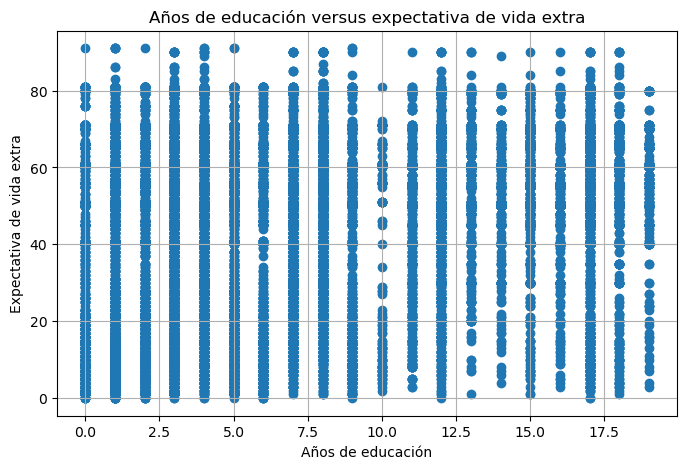

{'tags': ['hide_input']}

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df['edu'], df['Expectativa'], marker='o')  # usa plot para línea, marker='o' para puntos
plt.xlabel('Años de educación')  # nombre del eje x
plt.ylabel('Expectativa de vida extra')  # nombre del eje y
plt.title('Años de educación versus expectativa de vida extra')
plt.grid(True)
plt.show()

{"tags": ["hide_input"]}

# Pregunta 2
Ejecute un modelo Pooled OLS para estimar la relacion entre los anios de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [14]:
df2=df.dropna()
df2.columns

{"tags": ["hide_input"]}

{'tags': ['hide_input']}

In [15]:
model = smf.ols("Expectativa ~    C(year)+C(hombre)+ edad+ edu + C(region) + C(status) + C(kids) + C(situation) + exp+ wage+ hours + C(informal) + C(selfemp)+ C(publicemp)+ C(cotizando)+assets+exp_sist+C(cronica)+C(nocronica)+C(mental)", data=df2).fit()
print(model.summary())

{"tags": ["hide_input"]}

                            OLS Regression Results                            
Dep. Variable:            Expectativa   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     2693.
Date:                Tue, 20 May 2025   Prob (F-statistic):               0.00
Time:                        20:23:46   Log-Likelihood:            -1.8417e+05
No. Observations:               49229   AIC:                         3.684e+05
Df Residuals:                   49188   BIC:                         3.688e+05
Df Model:                          40                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              75.2608    

{'tags': ['hide_input']}

Basándonos en estos resultados, eliminaremos las variables región, exp, informal, selfemp y publicemp 

In [16]:
a=df.isna().sum().sum()
df.drop(["region","exp","informal","selfemp","publicemp"],axis=1,inplace=True)
df.dropna(inplace=True)
b=a=df.isna().sum().sum()
print(f'Se han eliminado {a-b} filas por tener un valor nulo')


{"tags": ["hide_input"]}

Se han eliminado 0 filas por tener un valor nulo


{'tags': ['hide_input']}

In [17]:
model = smf.ols("Expectativa ~ C(year)+C(hombre)+ edad+ edu + C(status) + C(kids) + C(situation)+ wage+ hours + C(cotizando)+assets+exp_sist+C(cronica)+C(nocronica)+C(mental)", data=df).fit()
print(model.summary())


{"tags": ["hide_input"]}

                            OLS Regression Results                            
Dep. Variable:            Expectativa   R-squared:                       0.684
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     4992.
Date:                Tue, 20 May 2025   Prob (F-statistic):               0.00
Time:                        20:23:48   Log-Likelihood:            -1.9021e+05
No. Observations:               50764   AIC:                         3.805e+05
Df Residuals:                   50741   BIC:                         3.807e+05
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              74.4869    

{'tags': ['hide_input']}

La interpretación de los resultados es como sigue: Para las variables continuas, por ejemplo edad, la expectativa de cuántos años más vivirá crece en 0.0891 años cuando los años de edcucación aumentan en 1, a excepción de la variable wage que, al estar estandarizada, se interpreta como que los años de vida que se espera vivir aumentan en 0.2135 cuando el sueldo aumenta en una desviación estándar. Para las variables catgóricas como hombre, se interpreta que cuando es hombre su expectativa de vida aumenta en 1.3582 con respecto a la categoría base (En este caso mujer).

# Pregunta 3
Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

 Eliminamos las variables que se podrían considerar fijas en el tiempo para un individuo como hombre, kids, cotizando, cronica, mental y status, para que no sean absorbidas.

In [18]:
df3=df
df3["yr"]=df3["year"]
df3=pd.get_dummies(df,columns=["yr","status","situation"],prefix=["yr","status","situation"],drop_first=True)
df3 = df3.set_index(["folio_n20","year"])
y=df3["Expectativa"]
X=df3[["edad","wage","nocronica", "edu",
      "yr_4","yr_6","yr_9","situation_2","situation_3","situation_4"]]


X=sm.add_constant(X)
model=lmp.PanelOLS(y,X, entity_effects=True)
fe=model.fit(cov_type="robust")
print(fe)

{"tags": ["hide_input"]}

                          PanelOLS Estimation Summary                           
Dep. Variable:            Expectativa   R-squared:                        0.0253
Estimator:                   PanelOLS   R-squared (Between):              0.7665
No. Observations:               50764   R-squared (Within):               0.0253
Date:                Tue, May 20 2025   R-squared (Overall):              0.6714
Time:                        20:23:49   Log-likelihood                -1.671e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      80.864
Entities:                       19566   P-value                           0.0000
Avg Obs:                       2.5945   Distribution:                F(10,31188)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             74.622
                            

{'tags': ['hide_input']}

En este caso, diriamos que cuando los años de educación aumentan en 1, los años de vida extra que se esperan vivir aumentan en 0.022. Como vemos, el valor p de la variable edu es muy alto, probablemente esto se deba a que luego de los 20 años, edad más baja en la que se comenzaron a realizar estas encuestas, los años de educación no suelen aumentar significativamente, por lo que podría considerarse como una variable fija en el tiempo para los individuos.

# Pregunta 4
Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [19]:
y=df3["Expectativa"]
X=df3[["edad","wage","nocronica","cronica","mental", "edu", "status_2.0","status_3.0","status_4.0",
       "status_5.0", "hombre","kids","cotizando",
      "yr_4","yr_6","yr_9","situation_2","situation_3","situation_4"]]
X=sm.add_constant(X)
model=lmp.RandomEffects(y,X)
re=model.fit(cov_type="robust")
print(re)


{"tags": ["hide_input"]}

                        RandomEffects Estimation Summary                        
Dep. Variable:            Expectativa   R-squared:                        0.5852
Estimator:              RandomEffects   R-squared (Between):              0.7784
No. Observations:               50764   R-squared (Within):               0.0213
Date:                Tue, May 20 2025   R-squared (Overall):              0.6821
Time:                        20:23:49   Log-likelihood                -1.795e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      3768.3
Entities:                       19566   P-value                           0.0000
Avg Obs:                       2.5945   Distribution:                F(19,50744)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             5508.4
                            

{'tags': ['hide_input']}

Según este modelo, al aumentar 1 año de educación la expectativa de vida extra aumenta en 0.0728 años. Como datos a destacar, las personas con situación cesante, trabajando e inactivo reportan entre 4 y 5 años menos de expectativa de vida extra que los que estan en la situación "otro". Sufrir una enfermedad no cronica parece disminuir la expectativa de vida más que sufrir una enfermedad crónica, probablemente porque aquellos que cuentan con una enfermedad crónica la conocen mejor y tienen una visión más realista de cómo los afectará. Los viudos parecen tener una expectativa de vida extra más alta que el resto, mientras que los solteros parecen tener una expectativa de vida extra más baja que el resto

Para el test de Hausman necesitamos correr los 2 modelos con las mismas variables, por lo que a continuación haremos RE con las mismas variables que FE

In [20]:
y=df3["Expectativa"]
X=df3[["edad","wage","nocronica", "edu",
      "yr_4","yr_6","yr_9","situation_2","situation_3","situation_4"]]
X=sm.add_constant(X)
model=lmp.RandomEffects(y,X)
re=model.fit(cov_type="robust")
print(re)

{"tags": ["hide_input"]}

                        RandomEffects Estimation Summary                        
Dep. Variable:            Expectativa   R-squared:                        0.5735
Estimator:              RandomEffects   R-squared (Between):              0.7688
No. Observations:               50764   R-squared (Within):               0.0233
Date:                Tue, May 20 2025   R-squared (Overall):              0.6735
Time:                        20:23:50   Log-likelihood                -1.795e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      6824.3
Entities:                       19566   P-value                           0.0000
Avg Obs:                       2.5945   Distribution:                F(10,50753)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             9821.9
                            

{'tags': ['hide_input']}

# Pregunta 5
Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [21]:
print(lmp.compare({"FE": fe, "RE": re}))


{"tags": ["hide_input"]}

                     Model Comparison                    
                                     FE                RE
---------------------------------------------------------
Dep. Variable               Expectativa       Expectativa
Estimator                      PanelOLS     RandomEffects
No. Observations                  50764             50764
Cov. Est.                        Robust            Robust
R-squared                        0.0253            0.5735
R-Squared (Within)               0.0253            0.0233
R-Squared (Between)              0.7665            0.7688
R-Squared (Overall)              0.6714            0.6735
F-statistic                      80.864            6824.3
P-value (F-stat)                 0.0000            0.0000
=====================     =============   ===============
const                            75.244            75.411
                               (38.499)          (50.360)
edad                            -0.8379           -0.8649
              

{'tags': ['hide_input']}

In [22]:
import numpy.linalg as la
from scipy import stats

def hausman(fe, re):
 diff = fe.params-re.params
 psi = fe.cov - re.cov
 dof = diff.size -1
 W = diff.dot(la.inv(psi)).dot(diff)
 pval = stats.chi2.sf(W, dof)
 return W, dof, pval

htest = hausman(fe, re) 
print("Hausman Test: chi-2 = {0}, df = {1}, p-value = {2}".format(htest[0], htest[1], htest[2]))


{"tags": ["hide_input"]}

Hausman Test: chi-2 = 148.74709696026045, df = 10, p-value = 6.746982004711178e-27


{'tags': ['hide_input']}

El valor p del test de Hausman es <0.05 lo que indica que hay efectos fijos no observados que se correlacionan con las variables Xit. Esto indica que no es conveniente usar MCO agrupados ni efectos aleatorios ya que esa correlación va en contra de sus supuestos, por lo que el mejor modelo será el de Efectos fijos. Aún así, la pregunta de estudio es sobre la relación entre la expectativa de vida y los años de estudio, esta última siendo una variable que varía poco en el tiempo en cada individuo, por lo que quizá efectos aleatorios pudiera ser más conveniente en este caso específico.
Las variables edad, no cronica y situation 2 presentaron pocas variaciones por lo que diremos que son robustas a la especifícación.

# Pregunta 6
Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

In [23]:
vars_base = ["edad","wage","nocronica", "edu",
      "yr_4","yr_6","yr_9","situation_2","situation_3","situation_4"]
for var in vars_base:
    df3[f'{var}_mean'] = df3.groupby('folio_n20')[var].transform('mean')
    
y = df3["Expectativa"]

X = df3[vars_base + [f'{var}_mean' for var in vars_base]]
X.drop(["yr_4_mean","yr_6_mean","yr_9_mean"],axis=1,inplace=True)
X=sm.add_constant(X)


model = lmp.RandomEffects(y, X)
cre = model.fit(cov_type='robust')
print(cre)


{"tags": ["hide_input"]}

                        RandomEffects Estimation Summary                        
Dep. Variable:            Expectativa   R-squared:                        0.5746
Estimator:              RandomEffects   R-squared (Between):              0.7698
No. Observations:               50764   R-squared (Within):               0.0247
Date:                Tue, May 20 2025   R-squared (Overall):              0.6748
Time:                        20:23:50   Log-likelihood                -1.794e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      4032.7
Entities:                       19566   P-value                           0.0000
Avg Obs:                       2.5945   Distribution:                F(17,50746)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             5812.7
                            

{'tags': ['hide_input']}

Hay varias medias de las variables que son significativas, esto viola el supuesto del modelo RE clásico, que exige que los efectos no observados no estén correlacionados con las explicativas, por lo que podríamos decir que este modelo es válido. También destacar que el coeficiente de la variable edu es negativo, indicando que a más años de estudio disminuye la expectativa de vida extra en 0.0026, esto podría explicarse pensando que mientras más años de estudio tiene una persona esta es más vieja, por lo que espera vivir menos años extra. Aunque ambién es un número muy pequeño, considerando que el mayor valor de edu es 19, su expectativa de vida se vería reducida en 0.0494 años, por lo que en este modelo la variable edu es bastante irrelevante.

# Pregunta 7
Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

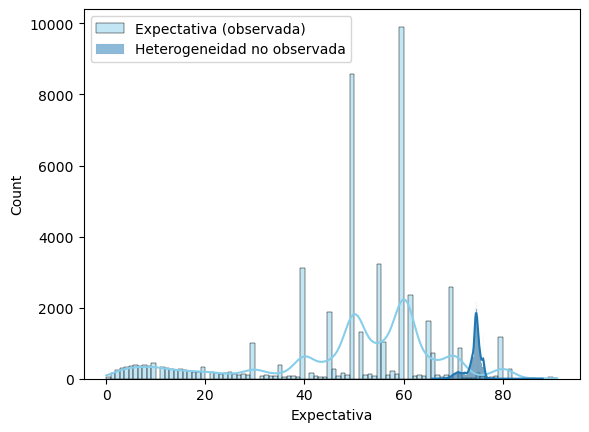

{'tags': ['hide_input']}

In [24]:
Xpred = X
Xpred['edad']=0
Xpred['wage']=0
Xpred['nocronica']=0
Xpred['edu']=0
Xpred['yr_4']=0
Xpred['yr_6']=0
Xpred['yr_9']=0
Xpred['situation_2']=0
Xpred['situation_3']=0
Xpred['situation_4']=0
yhat = cre.predict(Xpred)

sns.histplot(data=y, color="skyblue", label="Expectativa (observada)", kde=True)
sns.histplot(data=yhat, color="red", label="Heterogeneidad no observada", kde=True)

plt.legend() 
plt.show()

{"tags": ["hide_input"]}

Podemos ver que hay una gran concentración en números multiplos de 10, común en variables autorreportadas. La sección en azul oscuro representa las diferencias no observadas entre individuos como, actitudes, genética, estilos de vida no medidos, etc. El modelo CRE logra capturar una fracción relevante de las diferencias en expectativa de vida no explicadas por las variables observadas. Sin embargo, la forma más estrecha de la distribución azul oscuro frente a la más dispersa y ruidosa de la observada refleja que parte de la variación observada proviene del ruido o subjetividad en la medición y que la heterogeneidad estructural no observada es más estable y concentrada en torno a valores medios entre 70 y 75 años.

# Pregunta 8
Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

In [25]:
print(lmp.compare({"FE": fe, "RE": re, "CRE": cre}))

{"tags": ["hide_input"]}

                              Model Comparison                             
                                     FE                RE               CRE
---------------------------------------------------------------------------
Dep. Variable               Expectativa       Expectativa       Expectativa
Estimator                      PanelOLS     RandomEffects     RandomEffects
No. Observations                  50764             50764             50764
Cov. Est.                        Robust            Robust            Robust
R-squared                        0.0253            0.5735            0.5746
R-Squared (Within)               0.0253            0.0233            0.0247
R-Squared (Between)              0.7665            0.7688            0.7698
R-Squared (Overall)              0.6714            0.6735            0.6748
F-statistic                      80.864            6824.3            4032.7
P-value (F-stat)                 0.0000            0.0000            0.0000
============

{'tags': ['hide_input']}

Respecto de las variables analizadas en los 3 modelos, podemos decir que en general a más edad disminuye la espectativa de vida extra lo cuál es bastante obvio, pero destaco que ninguno de los coeficientes de la variable edad es >=1, es decir, vivir un año más no hace que esperes vivir un año menos, esto probablemente se deba a que cuando la gente llega a cierta edad y se da cuenta de que está mejor de lo que esperaba, aumenta la cantidad de años que espera vivir. El salario tiene un coeficiente muy distinto en RE con respecto a los otros 2 modelos, probablemente porque el coeficiente de su media es significativo, indicando que tiene efectos no observados correlacionados, lo que hace que el modelo RE sea ineficiente. Tener una enfermedad no crónica parece disminuir la expectativa de vida extra con respecto a no tenerla en alrededor de un año en los 3 modelos. Estar cesante, trabajando e inactivo parece disminuir la cantidad de años de vida extra esperados en entre 4 y 5 años en los 3 modelos con respecto a la situación otro. Previamente teorizamos que quienes están en la situación otro probablemente sean estudiantes con muchos años de vida por delante. Parece ser que en los años 2, 4, 6 y 9 la expectativa de vida extra ha ido en aumento, lo que se corresponde con la realidad de que las personas cada vez viven más gracias a los avances en la medicina. Por último, nuesta variable de estudio, los años de educación tienen 3 coeficientes muy cercanos a 0, uno incluso negativo y en los modelos FE y CRE cuenta con un valor p>0.05, por lo que podemos decir que la variable edu no es relevante para la expectativa de vida extra.

Considero que el modelo más eficiente sería el CRE dado que estima efectos aleatorios de forma más eficiente y controla correlaciones entre variables explicativas y efectos individuales no observados que sospecho que hay y relacionados con la variable edu.

# Pregunta 9
Bonus track (optativo): Es posible que sus resultados anteriores tengan sesgo dado que quienes esperan vivir mas pueden estar incentivados a adquirir mas educacion. Proponga AL MENOS DOS instrumentos posibles para predecir el nivel de educacion de forma exogena, tal que se pueda corregir el sesgo y entender el efecto causal de las educacion en la expectativa de vida. Realice su estimacion considerando un modelo agrupado (ignorando el tiempo), y el modelo de panel.

Para corregir ese sesgo y estimar el efecto causal de la educación sobre la expectativa de vida, se pueden usar variables instrumentales que sean relevantes y exógenas a la expectativa de vida extra. Podrían ser variables como la cantidad mínima de años de escolarización en la época en que el sujeto era estudiante y la distancia al centro educativo más cercano durante la infancia, ya que estas variables no afectan a la expectativa de vida directamente sino solo a través de la variable edu.

# Transformación a PDF

In [26]:
!jupyter nbconvert --to pdf --TagRemovePreprocessor.enabled=True --TagRemovePreprocessor.remove_input_tags="['hide_input']" Tarea2_Meza_Núñez.ipynb

C:\Users\franm\anaconda3\lib\site-packages\traitlets\traitlets.py:2915: FutureWarning: --TagRemovePreprocessor.remove_input_tags=['hide_input'] for containers is deprecated in traitlets 5.0. You can pass `--TagRemovePreprocessor.remove_input_tags item` ... multiple times to add items to a list.
  warn(
[NbConvertApp] Converting notebook Tarea2_Meza_Núñez.ipynb to pdf
C:\Users\franm\anaconda3\lib\site-packages\nbconvert\utils\pandoc.py:51: RuntimeWarning: You are using an unsupported version of pandoc (3.6.4).
Your version must be at least (1.12.1) but less than (3.0.0).
Refer to https://pandoc.org/installing.html.
Continuing with doubts...
  check_pandoc_version()
[NbConvertApp] Support files will be in Tarea2_Meza_Núñez_files\
[NbConvertApp] Making directory .\Tarea2_Meza_Núñez_files
[NbConvertApp] Making directory .\Tarea2_Meza_Núñez_files
[NbConvertApp] Making directory .\Tarea2_Meza_Núñez_files
[NbConvertApp] Writing 119989 bytes to notebook.tex
[NbConvertApp] Building PDF
Tracebac